In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_excel('Hospital data.xlsx')
df

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35
0,25312,118,68.0,22.730000,0,Caucasian,M,180.3,73.9,92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59342,81,77.0,27.420000,0,Caucasian,F,160.0,70.2,90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50777,118,25.0,31.950000,0,Caucasian,F,172.7,95.3,93,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,46918,118,81.0,22.640000,1,Caucasian,F,165.1,61.7,92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,34377,33,19.0,NaN,0,Caucasian,M,188.0,NaN,91,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91708,78108,30,75.0,23.060250,0,Caucasian,M,177.8,72.9,927,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91709,13486,121,56.0,47.179671,0,Caucasian,F,183.0,158.0,925,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91710,58179,195,48.0,27.236914,0,Caucasian,M,170.2,78.9,908,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91711,120598,66,NaN,23.297481,0,Caucasian,F,154.9,55.9,922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df.drop(columns = df.filter(like = 'Unnamed:').columns)
df

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
0,25312,118,68.0,22.730000,0,Caucasian,M,180.3,73.9,92,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,119.0
1,59342,81,77.0,27.420000,0,Caucasian,F,160.0,70.2,90,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,118.0
2,50777,118,25.0,31.950000,0,Caucasian,F,172.7,95.3,93,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,96.0
3,46918,118,81.0,22.640000,1,Caucasian,F,165.1,61.7,92,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,116.0
4,34377,33,19.0,NaN,0,Caucasian,M,188.0,NaN,91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,89.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91708,78108,30,75.0,23.060250,0,Caucasian,M,177.8,72.9,927,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,115.0
91709,13486,121,56.0,47.179671,0,Caucasian,F,183.0,158.0,925,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,100.0
91710,58179,195,48.0,27.236914,0,Caucasian,M,170.2,78.9,908,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,158.0
91711,120598,66,NaN,23.297481,0,Caucasian,F,154.9,55.9,922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,82.0


# Performing Basic Checks

In [4]:
df.shape

(91713, 25)

# There are 91713 Rows and 25 Columns

In [5]:
df.head()

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
0,25312,118,68.0,22.73,0,Caucasian,M,180.3,73.9,92,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,119.0
1,59342,81,77.0,27.42,0,Caucasian,F,160.0,70.2,90,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,118.0
2,50777,118,25.0,31.95,0,Caucasian,F,172.7,95.3,93,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,96.0
3,46918,118,81.0,22.64,1,Caucasian,F,165.1,61.7,92,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,116.0
4,34377,33,19.0,NaN,0,Caucasian,M,188.0,NaN,91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,89.0


In [6]:
df.tail()

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
91708,78108,30,75.0,23.060250,0,Caucasian,M,177.8,72.9,927,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,115.0
91709,13486,121,56.0,47.179671,0,Caucasian,F,183.0,158.0,925,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,100.0
91710,58179,195,48.0,27.236914,0,Caucasian,M,170.2,78.9,908,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,158.0
91711,120598,66,NaN,23.297481,0,Caucasian,F,154.9,55.9,922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,82.0
91712,53612,104,82.0,22.031250,1,Caucasian,F,160.0,56.4,926,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,104.0


# Data Type Overview 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     91713 non-null  int64  
 1   hospital_id                    91713 non-null  int64  
 2   age                            87485 non-null  float64
 3   bmi                            88284 non-null  float64
 4   elective_surgery               91713 non-null  int64  
 5   ethnicity                      90318 non-null  object 
 6   gender                         91688 non-null  object 
 7   height                         90379 non-null  float64
 8   weight                         88993 non-null  float64
 9   icu_id                         91713 non-null  int64  
 10  icu_stay_type                  91713 non-null  object 
 11  icu_type                       91713 non-null  object 
 12  pre_icu_los_days               91713 non-null 

# Statistical Summary

In [8]:
df.describe()

,patient_id,hospital_id,age,bmi,elective_surgery,height,weight,icu_id,pre_icu_los_days,apache_4a_hospital_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
count,91713.000000,91713.000000,87485.000000,88284.000000,91713.000000,90379.000000,88993.000000,91713.000000,91713.000000,83766.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,91713.000000,91568.000000
mean,65537.131464,105.669262,62.309516,29.185818,0.183736,169.641588,84.028340,508.357692,0.835766,0.086787,0.000857,0.015693,0.225192,0.012989,0.026165,0.007066,0.004132,0.020638,0.086302,103.000568
std,37811.252183,62.854406,16.775119,8.275142,0.387271,10.795378,25.011497,228.989661,2.487756,0.247569,0.029265,0.124284,0.417711,0.113229,0.159628,0.083763,0.064148,0.142169,0.280811,22.017346
min,1.000000,2.000000,16.000000,14.844926,0.000000,137.200000,38.600000,82.000000,-24.947222,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,58.000000
25%,32830.000000,47.000000,52.000000,23.641975,0.000000,162.500000,66.800000,369.000000,0.035417,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,87.000000
50%,65413.000000,109.000000,65.000000,27.654655,0.000000,170.100000,80.300000,504.000000,0.138889,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,101.000000
75%,98298.000000,161.000000,75.000000,32.930206,0.000000,177.800000,97.100000,679.000000,0.409028,0.130000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,116.000000
max,131051.000000,204.000000,89.000000,67.814990,1.000000,195.590000,186.000000,927.000000,159.090972,0.990000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,177.000000


In [9]:
df.describe(include =object)

,ethnicity,gender,icu_stay_type,icu_type,icu_admit_source
count,90318,91688,91713,91713,91601
unique,6,2,3,8,5
top,Caucasian,M,admit,Med-Surg ICU,Accident & Emergency
freq,70684,49469,86183,50586,54060


# Before Involving in Cleaning Process We Want To Change The Data Types of Following:
# Age = int;
# All 8 Comorbidity = int;
# Heart rate = int;

In [10]:
# Type casting [.astype()]
int_col = [
    'age',
    'aids',
    'cirrhosis',
    'diabetes_mellitus',
    'hepatic_failure',
    'immunosuppression',
    'leukemia',
    'lymphoma',
    'solid_tumor_with_metastasis',
    'd1_heartrate_max'
]
    

In [11]:
df[int_col]=df[int_col].astype('Int64')

In [12]:
df

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
0,25312,118,68,22.730000,0,Caucasian,M,180.3,73.9,92,...,0,0,1,0,0,0,0,0,0,119
1,59342,81,77,27.420000,0,Caucasian,F,160.0,70.2,90,...,0,0,1,0,0,0,0,0,0,118
2,50777,118,25,31.950000,0,Caucasian,F,172.7,95.3,93,...,0,0,0,0,0,0,0,0,0,96
3,46918,118,81,22.640000,1,Caucasian,F,165.1,61.7,92,...,0,0,0,0,0,0,0,0,0,116
4,34377,33,19,NaN,0,Caucasian,M,188.0,NaN,91,...,0,0,0,0,0,0,0,0,0,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91708,78108,30,75,23.060250,0,Caucasian,M,177.8,72.9,927,...,0,0,1,0,0,0,0,1,0,115
91709,13486,121,56,47.179671,0,Caucasian,F,183.0,158.0,925,...,0,0,0,0,0,0,0,0,0,100
91710,58179,195,48,27.236914,0,Caucasian,M,170.2,78.9,908,...,0,0,1,0,0,0,0,0,0,158
91711,120598,66,<NA>,23.297481,0,Caucasian,F,154.9,55.9,922,...,0,0,0,0,0,0,0,0,0,82


In [13]:
print(df.ethnicity.value_counts())
print(df.gender.value_counts())
print(df.icu_stay_type.value_counts())
print(df.icu_type.value_counts())
print(df.icu_admit_source.value_counts())

ethnicity
Caucasian           70684
African American     9547
Other/Unknown        4374
Hispanic             3796
Asian                1129
Native American       788
Name: count, dtype: int64
gender
M    49469
F    42219
Name: count, dtype: int64
icu_stay_type
admit       86183
transfer     4970
readmit       560
Name: count, dtype: int64
icu_type
Med-Surg ICU    50586
MICU             7695
Neuro ICU        7675
CCU-CTICU        7156
SICU             5209
Cardiac ICU      4776
CSICU            4613
CTICU            4003
Name: count, dtype: int64
icu_admit_source
Accident & Emergency         54060
Operating Room / Recovery    18713
Floor                        15611
Other Hospital                2358
Other ICU                      859
Name: count, dtype: int64


# Missing Value Analysis;

In [14]:
df.isnull().sum()

patient_id                          0
hospital_id                         0
age                              4228
bmi                              3429
elective_surgery                    0
ethnicity                        1395
gender                             25
height                           1334
weight                           2720
icu_id                              0
icu_stay_type                       0
icu_type                            0
pre_icu_los_days                    0
icu_admit_source                  112
apache_4a_hospital_death_prob    7947
aids                              715
cirrhosis                         715
diabetes_mellitus                 715
hepatic_failure                   715
immunosuppression                 715
leukemia                          715
lymphoma                          715
solid_tumor_with_metastasis       715
hospital_death                      0
d1_heartrate_max                  145
dtype: int64

# Duplicate Check

In [15]:
df.duplicated().sum()

0

# 1. Handling Missing Values in Age;

In [16]:
df.loc[df['age'].isnull()]

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
28,71020,118,<NA>,NaN,1,Caucasian,F,160.0,NaN,114,...,0,0,1,0,0,0,0,0,0,177
72,17332,118,<NA>,NaN,0,Caucasian,F,167.6,NaN,114,...,0,0,0,0,0,0,0,0,0,88
145,129948,31,<NA>,24.547736,0,Caucasian,M,180.3,79.8,83,...,0,0,0,0,0,0,0,0,0,142
174,63129,33,<NA>,28.359375,0,Caucasian,F,160.0,72.6,91,...,0,0,1,0,0,0,0,0,0,108
183,52796,69,<NA>,NaN,0,Caucasian,F,165.1,NaN,82,...,0,0,0,0,0,0,0,0,0,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91674,90374,121,<NA>,19.994961,0,Caucasian,F,157.5,49.6,925,...,0,0,0,0,0,1,0,0,0,120
91689,27439,6,<NA>,24.445450,0,Caucasian,M,188.0,86.4,918,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,120
91693,57515,183,<NA>,18.526701,0,Caucasian,M,178.0,58.7,909,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,126
91707,34638,183,<NA>,33.933518,0,Caucasian,F,152.0,78.4,909,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,100


<Axes: xlabel='age', ylabel='Count'>

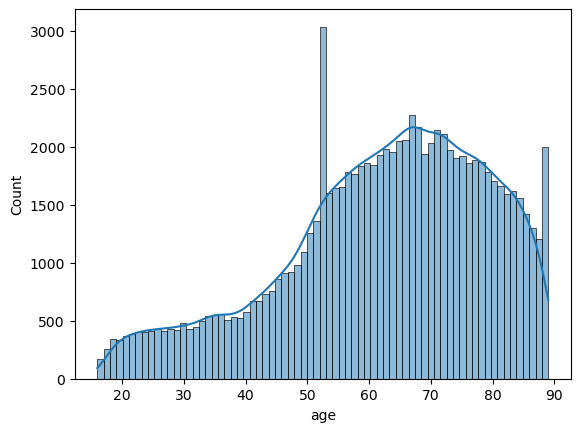

In [17]:
sns.histplot(data = df, x = 'age', kde = True)

# Because of Non-normal Distribution, the missing values will be replaced by Median.

In [18]:
df.age.median()

65.0

In [19]:
df.loc[df['age'].isnull(),'age']= df.age.median()

In [20]:
df.isnull().sum()

patient_id                          0
hospital_id                         0
age                                 0
bmi                              3429
elective_surgery                    0
ethnicity                        1395
gender                             25
height                           1334
weight                           2720
icu_id                              0
icu_stay_type                       0
icu_type                            0
pre_icu_los_days                    0
icu_admit_source                  112
apache_4a_hospital_death_prob    7947
aids                              715
cirrhosis                         715
diabetes_mellitus                 715
hepatic_failure                   715
immunosuppression                 715
leukemia                          715
lymphoma                          715
solid_tumor_with_metastasis       715
hospital_death                      0
d1_heartrate_max                  145
dtype: int64

# 2. Handling Missing Values in BMI;

In [21]:
df.loc[df['bmi'].isnull()]

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
4,34377,33,19,NaN,0,Caucasian,M,188.0,NaN,91,...,0,0,0,0,0,0,0,0,0,89
7,50129,33,70,NaN,0,Caucasian,M,165.0,NaN,91,...,0,0,0,0,1,0,0,0,0,118
8,10577,118,45,NaN,0,Caucasian,M,170.2,NaN,114,...,0,0,0,0,0,0,0,0,1,82
12,41311,118,48,NaN,0,Caucasian,M,175.3,NaN,102,...,0,0,0,0,0,0,0,0,0,106
13,103766,118,65,NaN,1,Caucasian,M,172.7,NaN,93,...,0,0,0,0,0,0,0,0,0,116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91216,44683,30,19,NaN,0,Caucasian,F,NaN,74.9,921,...,0,0,0,0,0,0,0,0,0,90
91327,126303,30,72,NaN,0,Caucasian,F,NaN,101.6,927,...,0,1,1,0,0,0,0,0,0,88
91472,119959,104,77,NaN,0,Hispanic,M,NaN,91.4,926,...,0,0,0,0,0,0,0,0,0,96
91627,5321,104,65,NaN,0,Caucasian,F,NaN,69.7,926,...,0,0,0,0,0,0,0,0,0,101


<Axes: xlabel='bmi', ylabel='Count'>

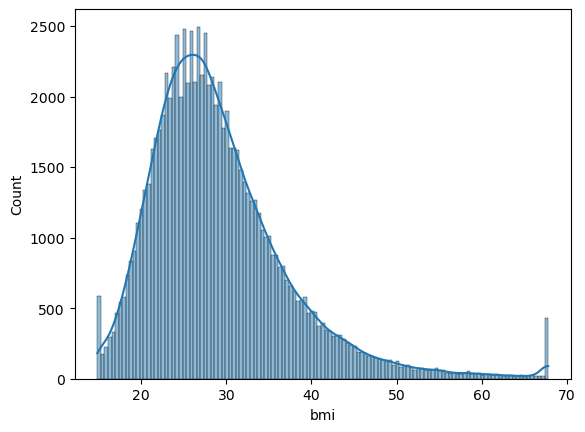

In [22]:
sns.histplot(data = df, x = 'bmi', kde= True)

# Because of Non-normal Distribution, the missing values will be replaced by Median

In [23]:
df.bmi.median()

27.65465458

In [24]:
df.loc[df['bmi'].isnull(),'bmi']= df.bmi.median()

In [25]:
df.isnull().sum()

patient_id                          0
hospital_id                         0
age                                 0
bmi                                 0
elective_surgery                    0
ethnicity                        1395
gender                             25
height                           1334
weight                           2720
icu_id                              0
icu_stay_type                       0
icu_type                            0
pre_icu_los_days                    0
icu_admit_source                  112
apache_4a_hospital_death_prob    7947
aids                              715
cirrhosis                         715
diabetes_mellitus                 715
hepatic_failure                   715
immunosuppression                 715
leukemia                          715
lymphoma                          715
solid_tumor_with_metastasis       715
hospital_death                      0
d1_heartrate_max                  145
dtype: int64

# 3. Handling Missing Values in Ethnicity;

df.loc[df['ethnicity'].isnull()]

# Replacing the Missing Values with "Mixed"

In [26]:
df.ethnicity.value_counts()

ethnicity
Caucasian           70684
African American     9547
Other/Unknown        4374
Hispanic             3796
Asian                1129
Native American       788
Name: count, dtype: int64

In [27]:
df['ethnicity'] = df['ethnicity'].fillna('Mixed')

In [28]:
df.ethnicity.value_counts()

ethnicity
Caucasian           70684
African American     9547
Other/Unknown        4374
Hispanic             3796
Mixed                1395
Asian                1129
Native American       788
Name: count, dtype: int64

# 4. Handling Missing Values in Gender;
Preserving all 25 records instead of deleting them that Creates a separate category for missing values. Only 25 values of data, so minimal impact on analysis Follows the same pattern as the ethnicity cleaning

In [29]:
df.loc[df['gender'].isnull()]

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
1177,72373,83,65,27.654655,0,Mixed,NaN,NaN,49.90,95,...,0,0,0,0,0,0,0,0,1,145
8514,6044,34,32,37.529120,0,Mixed,NaN,180.3,122.00,170,...,0,0,0,0,0,0,0,0,0,116
8675,120136,34,82,32.489796,0,Mixed,NaN,175.0,99.50,170,...,0,0,0,0,0,0,0,0,0,114
11728,118474,57,58,25.175510,0,Mixed,NaN,175.0,77.10,176,...,0,0,0,0,0,0,0,0,0,71
12417,35890,177,81,27.654655,0,Mixed,NaN,NaN,NaN,248,...,0,0,0,0,0,0,0,0,1,112
13765,9579,85,35,29.059466,0,Mixed,NaN,175.3,89.30,195,...,0,0,0,0,0,0,0,0,0,82
13913,70189,85,75,31.877288,0,Caucasian,NaN,178.0,101.00,195,...,0,0,0,0,0,0,0,0,0,<NA>
14142,65337,134,31,26.331925,0,Mixed,NaN,185.9,91.00,174,...,0,0,0,0,0,0,0,0,0,69
14563,53571,85,19,24.767142,0,Other/Unknown,NaN,157.4,61.36,195,...,0,0,0,0,0,0,0,0,0,58
26730,5845,55,40,42.802768,0,African American,NaN,170.0,123.70,391,...,0,0,0,0,0,0,0,0,0,98


# Replacing the missing values with 'Unknown'

In [30]:
df.gender.value_counts()

gender
M    49469
F    42219
Name: count, dtype: int64

In [31]:
df['gender'] = df['gender'].fillna('Unknown')

In [32]:
df.gender.value_counts()

gender
M          49469
F          42219
Unknown       25
Name: count, dtype: int64

In [33]:
df.isnull().sum()

patient_id                          0
hospital_id                         0
age                                 0
bmi                                 0
elective_surgery                    0
ethnicity                           0
gender                              0
height                           1334
weight                           2720
icu_id                              0
icu_stay_type                       0
icu_type                            0
pre_icu_los_days                    0
icu_admit_source                  112
apache_4a_hospital_death_prob    7947
aids                              715
cirrhosis                         715
diabetes_mellitus                 715
hepatic_failure                   715
immunosuppression                 715
leukemia                          715
lymphoma                          715
solid_tumor_with_metastasis       715
hospital_death                      0
d1_heartrate_max                  145
dtype: int64

# Leaving the missing values in Height & weight category as it is, Because filling or replacing those values in a hospital data is not appropriate and fair.

# 5. Handling Missing Values in ICU Admit Source;

In [34]:
df.loc[df['icu_admit_source'].isnull()]

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
962,63301,149,64,27.654655,0,Caucasian,M,NaN,NaN,103,...,0,0,0,0,0,0,0,0,0,70
1892,81289,33,46,27.654655,0,Caucasian,M,NaN,NaN,91,...,0,0,0,0,0,0,0,0,0,98
3930,33900,149,61,27.654655,0,Caucasian,M,NaN,NaN,103,...,0,0,0,0,0,0,0,0,0,81
4092,90248,149,76,27.038943,0,Caucasian,F,152.4,62.8,103,...,0,0,0,0,0,0,0,0,0,85
6148,50940,46,22,27.654655,0,Caucasian,M,NaN,NaN,98,...,0,0,0,0,0,0,0,0,0,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81299,48170,196,49,40.588227,1,Caucasian,F,163.8,108.9,772,...,0,0,0,0,0,0,0,0,0,94
85316,96629,35,77,28.577911,1,Caucasian,M,182.9,95.6,895,...,0,0,1,0,0,0,0,0,0,83
90287,83186,36,69,29.371047,0,Caucasian,M,172.7,87.6,905,...,0,0,0,0,0,0,0,0,0,100
90368,72890,167,37,27.654655,0,Caucasian,M,NaN,NaN,903,...,0,0,0,0,0,0,0,0,0,147


In [35]:
df.icu_admit_source.value_counts()

icu_admit_source
Accident & Emergency         54060
Operating Room / Recovery    18713
Floor                        15611
Other Hospital                2358
Other ICU                      859
Name: count, dtype: int64

In [36]:
df['icu_admit_source']= df['icu_admit_source'].fillna('Unknown')

In [37]:
df.icu_admit_source.value_counts()

icu_admit_source
Accident & Emergency         54060
Operating Room / Recovery    18713
Floor                        15611
Other Hospital                2358
Other ICU                      859
Unknown                        112
Name: count, dtype: int64

In [38]:
df.isnull().sum()

patient_id                          0
hospital_id                         0
age                                 0
bmi                                 0
elective_surgery                    0
ethnicity                           0
gender                              0
height                           1334
weight                           2720
icu_id                              0
icu_stay_type                       0
icu_type                            0
pre_icu_los_days                    0
icu_admit_source                    0
apache_4a_hospital_death_prob    7947
aids                              715
cirrhosis                         715
diabetes_mellitus                 715
hepatic_failure                   715
immunosuppression                 715
leukemia                          715
lymphoma                          715
solid_tumor_with_metastasis       715
hospital_death                      0
d1_heartrate_max                  145
dtype: int64

# 6. Handling Missing Values in 'apache_4a_hospital_death_prob';

In [39]:
df.loc[df['apache_4a_hospital_death_prob'].isnull()]

,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,weight,icu_id,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death,d1_heartrate_max
4,34377,33,19,27.654655,0,Caucasian,M,188.0,NaN,91,...,0,0,0,0,0,0,0,0,0,89
8,10577,118,45,27.654655,0,Caucasian,M,170.2,NaN,114,...,0,0,0,0,0,0,0,0,1,82
32,65066,77,30,17.003550,0,Caucasian,F,162.5,44.9,87,...,0,0,0,0,0,0,0,0,0,104
41,36199,77,60,27.654655,0,Caucasian,F,165.1,NaN,87,...,0,0,1,0,0,0,0,0,0,136
54,40415,118,84,27.654655,0,Caucasian,M,180.3,NaN,93,...,0,0,0,0,0,0,0,0,0,106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91628,27590,3,37,27.878788,0,Caucasian,F,165.0,75.9,917,...,0,0,0,0,0,0,0,0,0,125
91633,107321,3,81,27.465000,0,Caucasian,M,173.0,82.2,917,...,0,0,0,0,0,0,0,0,0,110
91689,27439,6,65,24.445450,0,Caucasian,M,188.0,86.4,918,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,120
91693,57515,183,65,18.526701,0,Caucasian,M,178.0,58.7,909,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,126


<Axes: xlabel='apache_4a_hospital_death_prob', ylabel='Count'>

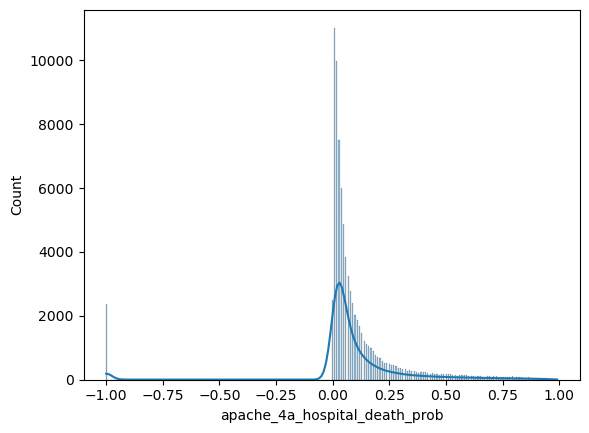

In [40]:
sns.histplot(data = df, x ='apache_4a_hospital_death_prob', kde = True)

# Because of Non-normal Distribution, the missing values will be replaced by Median

In [41]:
df.apache_4a_hospital_death_prob.median()

0.05

In [42]:
df.loc[df['apache_4a_hospital_death_prob'].isnull(),'apache_4a_hospital_death_prob'] = df.apache_4a_hospital_death_prob.median()

In [43]:
df.isnull().sum()

patient_id                          0
hospital_id                         0
age                                 0
bmi                                 0
elective_surgery                    0
ethnicity                           0
gender                              0
height                           1334
weight                           2720
icu_id                              0
icu_stay_type                       0
icu_type                            0
pre_icu_los_days                    0
icu_admit_source                    0
apache_4a_hospital_death_prob       0
aids                              715
cirrhosis                         715
diabetes_mellitus                 715
hepatic_failure                   715
immunosuppression                 715
leukemia                          715
lymphoma                          715
solid_tumor_with_metastasis       715
hospital_death                      0
d1_heartrate_max                  145
dtype: int64

# Leaving the missing values of Comorbidity & Heart rate as it is, as same thing already handled for height and weight categories.

# **Questions that need to Answer**
# 1. How Many Total deaths in Hospital and What is the Mortality Rate ?

In [44]:
total_deaths = (df['hospital_death'] == 1).sum()
mortality_rate = round(total_deaths * 100 / len(df), 2)
print(total_deaths)

7915


In [45]:
mortality_rate

8.63

In [46]:
a = {
    'Total Death in hospital':[total_deaths],
    'Mortality Rate': [mortality_rate]
}
a = pd.DataFrame(a)
a
    

,Total Death in hospital,Mortality Rate
0,7915,8.63


# 2.Death Count By Ethnicity?

In [47]:
q2 = df[df['hospital_death']==1].groupby('ethnicity')['hospital_death'].count().reset_index(name='total_death_count') 
q2['percentage'] = round(q2['total_death_count'] * 100 / q2['total_death_count'].sum(), 2)
q2

,ethnicity,total_death_count,percentage
0,African American,750,9.48
1,Asian,93,1.17
2,Caucasian,6168,77.93
3,Hispanic,376,4.75
4,Mixed,105,1.33
5,Native American,70,0.88
6,Other/Unknown,353,4.46


# 3. Death By Gender ?

In [48]:
q3 = df[df['hospital_death']==1].groupby('gender')['hospital_death'].count().reset_index(name='total_death')

In [49]:
q3

,gender,total_death
0,F,3731
1,M,4176
2,Unknown,8


# 4. Comparing the amount of patients that died and survived by each age 

In [50]:
# creating age intreval column
df['age_intreval']= pd.cut(df['age'],
                           bins =[0,10,20,30,40,50,60,70,80,90],
                           labels=['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89'],
                           right = False)

In [51]:
q4 = df.groupby('age_intreval')['hospital_death'].value_counts().unstack()
q4.columns = ['amount_that_survived','amount_that_died']
q4['percentage_that_died']= round(q4['amount_that_died']*100 / (q4['amount_that_died'] + q4['amount_that_survived']), 2)
q4 = q4[['amount_that_survived', 'amount_that_died', 'percentage_that_died']]
q4 = q4.reset_index()
q4

/tmp/ipykernel_330/872671538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q4 = df.groupby('age_intreval')['hospital_death'].value_counts().unstack()


,age_intreval,amount_that_survived,amount_that_died,percentage_that_died
0,0-9,0,0,NaN
1,10-19,752,20,2.59
2,20-29,3884,119,2.97
3,30-39,4865,211,4.16
4,40-49,7787,374,4.58
5,50-59,14927,991,6.23
6,60-69,21959,2321,9.56
7,70-79,17457,2006,10.31
8,80-89,12167,1873,13.34


# 5. Patients died and Survived between 60 to 100 ages

In [52]:
survived = ((df['age'] >= 60) & (df['age'] <= 100) & (df['hospital_death'] == 0)).sum()
died = ((df['age'] >= 60) & (df['age'] <= 100) & (df['hospital_death'] == 1)).sum()

q5 = pd.DataFrame({
    'Age': 'Greater than 60',
    'survived': [survived],
    'died': [died]
})
q5

,Age,survived,died
0,Greater than 60,51583,6200


# 6. Calculating the average probability of hospital death for patients of different age groups;

In [53]:
def age_group(age):
    if age < 40:
        return '0 - 40'
    elif age < 60:
        return '40 - 59'
    elif age < 80:
        return '60 - 79'
    else:
        return '80 & above'

In [54]:
df['age_group'] = df['age'].apply(age_group)

In [55]:
q6 = df.groupby('age_group')['apache_4a_hospital_death_prob'].mean().round(3).reset_index()
q6.columns= ['Age_group','Prob_hospital_death']

In [56]:
q6

,Age_group,Prob_hospital_death
0,0 - 40,0.030
1,40 - 59,0.053
2,60 - 79,0.096
3,80 & above,0.135


# 7. Which admit source of the ICU did most patients die in and get admitted to?

In [57]:
q7 = df.groupby('icu_admit_source')['hospital_death'].value_counts().unstack()
q7.columns = ['amt_that_survived','amt_that_died']
q7 =q7.reset_index()
q7

,icu_admit_source,amt_that_survived,amt_that_died
0,Accident & Emergency,49390,4670
1,Floor,13517,2094
2,Operating Room / Recovery,18015,698
3,Other Hospital,2041,317
4,Other ICU,735,124
5,Unknown,100,12


# 8. Average age of people in each ICU admit source;

In [58]:
q8 = df[df['hospital_death'] == 1].groupby('icu_admit_source').agg(
    amount_that_died=('hospital_death', 'count'),
    avg_age=('age', 'mean')
).round(2).reset_index()
q8

,icu_admit_source,amount_that_died,avg_age
0,Accident & Emergency,4670,67.58
1,Floor,2094,69.96
2,Operating Room / Recovery,698,69.26
3,Other Hospital,317,64.21
4,Other ICU,124,66.43
5,Unknown,12,70.08


# 9. Average age of people in each ICU Type and amount that died;

In [59]:
q9 = df[df['hospital_death'] == 1].groupby('icu_type').agg(
    amount_that_died=('hospital_death', 'count'),
    avg_age=('age', 'mean')
).round(2).reset_index()
q9

,icu_type,amount_that_died,avg_age
0,CCU-CTICU,542,68.99
1,CSICU,254,70.04
2,CTICU,241,68.9
3,Cardiac ICU,494,67.78
4,MICU,930,68.33
5,Med-Surg ICU,4426,68.16
6,Neuro ICU,638,67.58
7,SICU,390,67.43


# 10. Average weight, bmi, and max heartrate of people who died;

In [60]:
q10 = df[df['hospital_death'] == 1]
q10 = pd.DataFrame({
    'avg_weight': [q10['weight'].mean()],
    'avg_bmi': [q10['bmi'].mean()],
    'max_heartrate': [q10['d1_heartrate_max'].max()]
}).round(2)
q10

,avg_weight,avg_bmi,max_heartrate
0,80.9,28.31,177


# 11. Average BMI for each Ethnicity;

In [61]:
q11 = df.groupby('ethnicity')['bmi'].mean().round(2).reset_index()
q11.columns = ['Ethnicity','Avg_bmi']
q11

,Ethnicity,Avg_bmi
0,African American,29.98
1,Asian,25.52
2,Caucasian,29.12
3,Hispanic,28.36
4,Mixed,29.03
5,Native American,30.88
6,Other/Unknown,28.68


# 12. How many patients are suffering from each comorbidity?

In [62]:
comorbid_col = ['aids','cirrhosis','diabetes_mellitus','hepatic_failure','immunosuppression','leukemia','lymphoma','solid_tumor_with_metastasis']

In [63]:
q12 = df[comorbid_col].sum().reset_index()
q12.columns = ['Comorbidity','Patient_count']


In [66]:
q12.loc['Total'] = ['Total', q12['Patient_count'].sum()]
q12 = q12.reset_index(drop=True)
q12

,Comorbidity,Patient_count
0,aids,78
1,cirrhosis,1428
2,diabetes_mellitus,20492
3,hepatic_failure,1182
4,immunosuppression,2381
5,leukemia,643
6,lymphoma,376
7,solid_tumor_with_metastasis,1878
8,Total,28458


# 13. How many Patients died in each comorbidity ?

In [73]:
died = df[df['hospital_death'] == 1]

q13 = died[comorbid_col].sum().reset_index()
q13.columns = ['Comorbidity', 'Death_count']
q13.loc['Total'] = ['Total', q13['Death_count'].sum()]
q13 = q13.reset_index(drop=True)
q13

,Comorbidity,Death_count
0,aids,10
1,cirrhosis,248
2,diabetes_mellitus,1595
3,hepatic_failure,214
4,immunosuppression,384
5,leukemia,119
6,lymphoma,63
7,solid_tumor_with_metastasis,347
8,Total,2980


# 14. What was the average weight and height for male & female patients who underwent elective surgery?

In [69]:
q14 = df[df['elective_surgery']==1]
q14 = q14.groupby('gender')['height'].mean().round(2).reset_index(name='Avg_height')
q14

,gender,Avg_height
0,F,161.58
1,M,176.62


In [70]:
q15 = df[df['elective_surgery']==1]
q15 = q15.groupby('gender')['weight'].mean().round(2).reset_index(name='Avg_weight')
q15

,gender,Avg_weight
0,F,78.17
1,M,90.91


In [71]:
q15 = round((df['elective_surgery']==1).sum() * 100 / len(df),2)
print(q15 )

18.37


In [72]:
df.elective_surgery.sum()

16851

# Total patients underwent elective surgery = 16851
# Percentage of people underwent = 18.37%


# 15. What was the average length of stay at each ICU for patients who survived and those who didn't?

In [68]:
q16 = df.groupby('icu_type').apply(lambda x: pd.Series({
    'avg_icu_stay_death': round(x.loc[x['hospital_death'] == 1, 'pre_icu_los_days'].mean(), 2),
    'avg_icu_stay_survived': round(x.loc[x['hospital_death'] == 0, 'pre_icu_los_days'].mean(), 2)
})).reset_index()
q16

/tmp/ipykernel_330/691661974.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  q16 = df.groupby('icu_type').apply(lambda x: pd.Series({


,icu_type,avg_icu_stay_death,avg_icu_stay_survived
0,CCU-CTICU,1.20,0.75
1,CSICU,1.35,0.90
2,CTICU,2.09,1.68
3,Cardiac ICU,1.41,0.78
4,MICU,1.59,0.81
5,Med-Surg ICU,1.31,0.70
6,Neuro ICU,0.70,0.59
7,SICU,1.94,1.11


# 16. Finding out how many patients are in each BMI category based on their BMI value;

In [67]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)
q17 = df['bmi_category'].value_counts().reset_index()
q17.columns = ['bmi_category', 'patient_count']
q17

,bmi_category,patient_count
0,Obese,32918
1,Overweight,29570
2,Normal,25502
3,Underweight,3723
